# CIBUSmod Scenario example:<br/>Revisiting scenarios for organic farming in Sweden

This notebook provides an example run of CIBUSmod using two scenarios up until 2050; 'Base20' and 'Sust50' originally developed by Basnet *et al.* (2023).

**Base20:** A business-as-ususal scenario with assumptions on productivity improvements and population growth   
**Sust50:** A scenario with increased organic production (up to 50% of cropland) coupled with stronger productivity gains, reduced food waste and dietary changes towards less animal-source foods


Basnet, S., Wood, A., Röös, E., Jansson, T., Fetzer, I. & Gordon, L. (2023). Organic agriculture in a low-emission world: exploring combined measures to deliver a sustainable food system in Sweden. *Sustainability Science*, 18(1), 501-519. https://doi.org/10.1007/s11625-022-01279-9

## Set things up

Add directory with the CIBUSmod modules to path to be able to import

In [2]:
import sys
import os
sys.path.insert(0, os.path.join(os.getcwd(),'..'))

Import CIBUSmod and packages for handling data and plotting

In [3]:
import CIBUSmod as cm
import CIBUSmod.utils.plot as plot

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Instantiate a `Session` object and define scenarios.

In [4]:
years = list(range(2020,2050+1,5))

# Create session
session = cm.Session(
    name = 'example_scenarios',
    data_path = '../data'
)

# Define scenarios
session.add_scenario(
    name = 'Base20',
    scenario_workbooks = 'example_bau',
    years = years
)

# Define scenarios
session.add_scenario(
    name = 'Sust50',
    scenario_workbooks = ['example_bau', 'example_org_circ'],
    years = years
)

A scenario with the name 'Base20' already exists use .update_scenario() or .remove_scenario() instead.
A scenario with the name 'Sust50' already exists use .update_scenario() or .remove_scenario() instead.


Define some styling for plots

In [5]:
bar_style = {
    'ticklabels_fontsize' : 9,
    'grouplabels_fontsize' : 9,
    'ylabel_fontsize' : 10,
    'xlabel_fontsize' : 10,
    'cmap' : 'YlGnBu'
}

## Run calculations
The code below initiates a process pool that executes the model runs. The `max_workers` paramter to `ProcessPoolExecutor()` defines the maximum number of concurrent processes. The ideal value for this will depend on the computer. The code will print a message every time a scenario run has finnished and if a scenario run fails it will print an error message.

In [20]:
# Import
from concurrent.futures import ProcessPoolExecutor, as_completed
from multi_proc import do_run
import traceback

# Create list of scenarios/years to run
# runs = [(s,y) for s, y in session.iterate('all')]
runs = [(s,y) for s, y in session.iterate('Sust50')]
# runs = [('Sust50','2050')]
runs

[('Sust50', '2020'),
 ('Sust50', '2025'),
 ('Sust50', '2030'),
 ('Sust50', '2035'),
 ('Sust50', '2040'),
 ('Sust50', '2045'),
 ('Sust50', '2050')]

In [21]:
%%time

# Do the multi-processing
with ProcessPoolExecutor(max_workers=8) as executor:
    
    futures = {executor.submit(do_run, session, scn_year) : scn_year for scn_year in runs}

    for future in as_completed(futures):
    
        scn, year = futures[future]
           
        try:
            t = future.result()
        except Exception as ee:
            print(f'(!!!) {scn}, {year} failed with the exception: {ee}')
        else:
            m = int(t/60)
            s = int(round(t - m*60))
            
            print(f'{scn}, {year} finished successfully in {m}min {s}s')

session.cache.clear()

Sust50, 2025 finished successfully in 4min 9s
Sust50, 2050 finished successfully in 4min 20s
Sust50, 2040 finished successfully in 4min 20s
Sust50, 2035 finished successfully in 4min 22s
Sust50, 2020 finished successfully in 4min 25s
Sust50, 2030 finished successfully in 4min 26s
Sust50, 2045 finished successfully in 4min 34s
CPU times: total: 0 ns
Wall time: 4min 46s


## Plot output

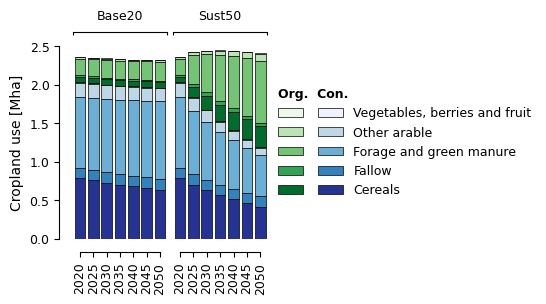

Share of cropland:


prod_system  conventional    organic  total
scn    year                                
Base20 2020     86.100469  13.899531  100.0
       2025     85.812129  14.187871  100.0
       2030     85.545823  14.454177  100.0
       2035     85.305494  14.694506  100.0
       2040     85.072618  14.927382  100.0
       2045     84.850385  15.149615  100.0
       2050     84.657736  15.342264  100.0
Sust50 2020     86.100469  13.899531  100.0
       2025     75.936787  24.063213  100.0
       2030     68.637168  31.362832  100.0
       2035     62.594820  37.405180  100.0
       2040     57.529010  42.470990  100.0
       2045     53.225399  46.774601  100.0
       2050     49.545246  50.454754  100.0

Total cropland area:


prod_system  conventional   organic     total
scn    year                                  
Base20 2020      2.027228  0.327263  2.354491
       2025      2.013744  0.332945  2.346689
       2030      1.999947  0.337919  2.337866
       2035      1.986461  0.342183  2.328644
       2040      1.976461  0.346802  2.323263
       2045      1.969010  0.351557  2.320567
       2050      1.960757  0.355342  2.316098
Sust50 2020      2.027228  0.327263  2.354491
       2025      1.838141  0.582479  2.420621
       2030      1.674836  0.765294  2.440129
       2035      1.529878  0.914219  2.444096
       2040      1.404027  1.036528  2.440554
       2045      1.292449  1.135807  2.428255
       2050      1.190589  1.212445  2.403034

Share "Forage and green manure":


prod_system  conventional    organic
scn    year                         
Base20 2020     45.050962  65.812100
       2025     46.323115  66.510630
       2030     47.495931  67.142454
       2035     48.618907  67.727785
       2040     49.693865  68.285555
       2045     50.720809  68.811311
       2050     51.688249  69.274251
Sust50 2020     45.050962  65.812100
       2025     44.930419  63.966951
       2030     44.915160  64.101520
       2035     44.883059  64.602821
       2040     44.903636  65.238646
       2045     44.981375  65.932546
       2050     45.099538  66.602899

Share "Cereals":


prod_system  conventional    organic
scn    year                         
Base20 2020     38.674485  23.149828
       2025     37.447598  22.756086
       2030     36.322550  22.398372
       2035     35.262473  22.065151
       2040     34.263134  21.751060
       2045     33.320961  21.456606
       2050     32.437921  21.196711
Sust50 2020     38.674485  23.149828
       2025     38.066519  22.534001
       2030     37.398228  22.603158
       2035     36.755252  22.613683
       2040     36.102999  22.596179
       2045     35.443130  22.559993
       2050     34.791974  22.519913

In [6]:
plot_data = (
    session.get_attr('c','area',{'prod_system':None, 'crop':['land_use','crop_group2']})
    .loc[:,(slice(None),'cropland')]
    .droplevel('land_use', axis=1)
    .rename(columns={'Fodder crops':'Forage and green manure'})
)/1_000_000

from matplotlib.colors import ListedColormap
colors = ['#253494', '#3182bd', '#6baed6','#bdd7e7' , '#eff3ff',
          '#006d2c', '#31a354', '#74c476', '#bae4b3', '#edf8e9']
cust_cmap = ListedColormap(name='X', colors=colors)

# Hide crop group for organic to make nice legend
plot_data_ = plot_data.copy()
plot_data_.columns = \
pd.MultiIndex.from_tuples(
    [(ps,cg) if ps != 'organic' else (ps,' ') for ps,cg in plot_data_.columns],
    names = plot_data_.columns.names
)

fig, ax = plt.subplots(figsize=(2.5,2.5))
cm.plot.bar(
    plot_data_.droplevel('prod_system', axis=1),
    ax=ax,
    group_levels='scn',
    sort_categories=False,
    ylabel='Cropland use [Mha]',
    **{k:v for k,v in bar_style.items() if k != 'cmap'},
    cmap=cust_cmap,
    ylim=(0,2.5)
)
ax.legend(
    loc='center left', bbox_to_anchor=(1.0, 0.5), ncol=2, frameon=False, reverse=True, fontsize=9,
    columnspacing = 0.1,
    title='Org.  Con.',
    title_fontproperties={'weight': 'bold', 'size': 9},  # Make title bold and adjust size
    alignment="left"  # Align legend text to the left
)
plt.show()

tab_data = plot_data.T.groupby('prod_system').sum().T
tab_data['total'] = tab_data.sum(axis=1)
tab_data2 = plot_data.T.groupby('prod_system').apply(lambda x: x/x.sum()*100).T.droplevel(0, axis=1)

print('Share of cropland:')
display(tab_data.apply(lambda x: x/x.total*100, axis=1))
print('Total cropland area:')
display(tab_data)
print('Share "Forage and green manure":')
display(tab_data2.xs('Forage and green manure', level='crop_group2', axis=1))
print('Share "Cereals":')
display(tab_data2.xs('Cereals', level='crop_group2', axis=1))

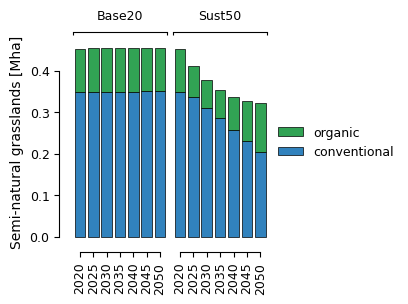

In [7]:
plot_data = (
    session.get_attr('c','area',{'prod_system':None, 'crop':'land_use'})
    .loc[:,(slice(None),'semi-natural grasslands')]
    .droplevel('land_use', axis=1)
)/1_000_000

from matplotlib.colors import ListedColormap
colors = ['#3182bd','#31a354']
cust_cmap = ListedColormap(name='X', colors=colors)

fig, ax = plt.subplots(figsize=(2.5,2.5))
cm.plot.bar(
    plot_data,
    ax=ax,
    group_levels='scn',
    sort_categories=False,
    ylabel='Semi-natural grasslands [Mha]',
    **{k:v for k,v in bar_style.items() if k != 'cmap'},
    cmap=cust_cmap
)
ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), ncol=1, fontsize=9, frameon=False, reverse=True)
plt.show()

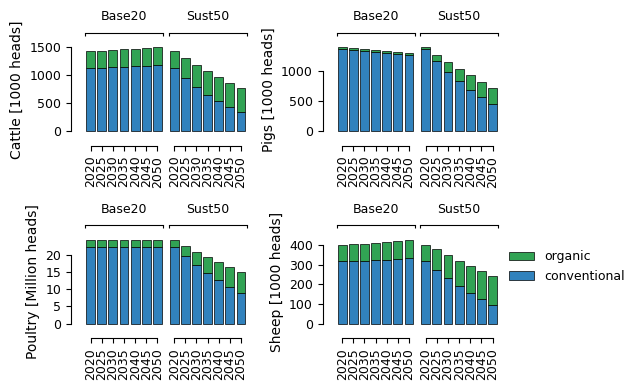

In [8]:
# Number of animal heads
plot_data = session.get_attr('A','heads',['species','prod_system'])

from matplotlib.colors import ListedColormap
colors = ['#3182bd','#31a354']
cust_cmap = ListedColormap(name='X', colors=colors)

fig, axs = plt.subplots(2,2, figsize=(6.5,4))

for ax,sp in zip(axs.flatten(),plot_data.drop('horses', axis=1).columns.get_level_values('species').unique()):

    cm.plot.bar(
        (plot_data / (1000000 if sp=='poultry' else 1000))
        .xs(sp, level='species', axis=1),
        **{k:v for k,v in bar_style.items() if k != 'cmap'},
        cmap=cust_cmap,
        ax=ax,
        group_levels='scn',
        ylabel=sp.capitalize() + (' [Million heads]' if sp=='poultry' else ' [1000 heads]')
    )

for ax in axs.flatten():
    ax.legend().set_visible(False)
ax.legend(loc='upper left', ncol=1, bbox_to_anchor=(1, 1), fontsize=9, frameon=False, reverse=True)

plt.tight_layout()
plt.show()

In [9]:
d = (
    session.get_attr('c','harvest',{'crop':['land_use',None],'prod_system':None})/
    session.get_attr('c','area',{'crop':['land_use',None],'prod_system':None})
).loc[[('Base20','2020'),('Base20','2050'),('Sust50','2050')],'cropland'] / 1_000

display(d.T.xs('conventional', level='prod_system', drop_level=False))
display(d.T.xs('organic', level='prod_system', drop_level=False))

scn                                                  Base20             \
year                                                   2020       2050   
crop                                prod_system                          
Apples                              conventional  18.341441  21.214879   
Barley, spring                      conventional   5.011251   5.974321   
Barley, winter                      conventional   6.371792   7.593095   
Beans, dry                          conventional   1.771157   1.768864   
Broad beans and horse beans, dry    conventional   3.288914   4.123896   
Buckwheat                           conventional   1.881309   1.660549   
Cabbages, cauliflowers and broccoli conventional  21.685775  27.105903   
Carrots                             conventional  67.405331  85.560708   
Cereals for fodder                  conventional   3.492660   3.496603   
Cucumbers                           conventional  62.124539  63.439060   
Currants                            conventional   1.479149   1.501637   
Energy grass                        conventional   4.026451   4.027127   
Fallow                              conventional   2.333292   2.331821   
Green manure                        conventional   4.808647   4.809145   
Herbs                               conventional   4.010174   5.099862   
Lettuce and spinach                 conventional  15.535112  19.693449   
Ley for fodder                      conventional   5.505731   5.519328   
Ley for grazing                     conventional   4.456469   4.486252   
Ley for seed                        conventional   0.650000   0.650000   
Ley not harvested                   conventional   3.972764   3.970473   
Maize (corn)                        conventional   6.096836   6.101068   
Maize for forage and silage         conventional  10.799012  10.760149   
Mixed cereals                       conventional   3.325068   3.298424   
Oats                                conventional   4.616728   5.747149   
Onions                              conventional  51.313992  65.056202   
Other berries                       conventional   1.689706   1.766983   
Other crops for fodder              conventional   4.333427   4.345815   
Other fruit                         conventional   4.566211   4.587298   
Other root vegetables               conventional  34.864153  43.970183   
Other vegetables                    conventional  14.942488  18.563246   
Pears                               conventional  15.645672  15.710540   
Peas, dry                           conventional   3.411177   4.267608   
Peas, green                         conventional   4.405018   4.421994   
Potatoes, starch                    conventional  45.169104  55.111164   
Potatoes, table                     conventional  38.294366  46.639726   
Pumpkins and squash                 conventional  27.210757  34.112795   
Quinoa                              conventional   1.305022   1.305022   
Rapeseed, spring                    conventional   1.836120   2.198589   
Rapeseed, winter                    conventional   3.554188   4.259217   
Rye                                 conventional   6.902911   8.623990   
Short rotation coppice              conventional   4.694914   4.694562   
Strawberries                        conventional   6.877322   6.887888   
Sugar beet                          conventional  76.508937  95.607454   
Triticale, spring                   conventional   3.307525   3.314277   
Triticale, winter                   conventional   5.753824   5.754469   
Wheat, spring                       conventional   4.629528   6.300168   
Wheat, winter                       conventional   7.246938   9.906368   

scn                                                   Sust50  
year                                                    2050  
crop                                prod_system               
Apples                              conventional   23.865900  
Barley, spring                      conventiona

scn                                              Base20                Sust50
year                                               2020       2050       2050
crop                             prod_system                                 
Apples                           organic       8.110380   8.105811   8.097400
Barley, spring                   organic       3.164292   3.266395   4.332912
Barley, winter                   organic       3.964937   4.084277   4.901641
Beans, dry                       organic       1.401524   1.695912   1.853231
Broad beans and horse beans, dry organic       2.348655   2.710352   3.511659
Buckwheat                        organic       1.528278  12.672125   0.854645
Carrots                          organic      58.650285  74.528878  80.997721
Cereals for fodder               organic       3.081181   3.080049   3.159965
Cucumbers                        organic      10.481964  13.309913  14.437451
Energy grass                     organic       3.567358   3.567666   3.695960
Fallow                           organic       2.240712   2.238231   2.333657
Green manure                     organic       4.500789   4.499723   4.919737
Herbs                            organic       0.876809   1.113531   1.228604
Lettuce and spinach              organic       5.840467   7.418623   8.040113
Ley for fodder                   organic       4.728248   4.732947   4.829197
Ley for grazing                  organic       3.804951   3.825310   3.923694
Ley for seed                     organic       0.400000   0.400000   0.400000
Ley not harvested                organic       3.542399   3.542392   3.787709
Maize (corn)                     organic       3.940218   3.940782   3.915072
Mixed cereals                    organic       2.697339   2.724256   3.317845
Oats                             organic       2.994105   3.116816   4.002558
Onions                           organic      25.815672  32.788673  35.559211
Other crops for fodder           organic       3.578871   3.584332   3.636061
Other root vegetables            organic       7.246370   9.204325   9.997728
Other vegetables                 organic       3.171410   4.025948   4.332509
Pears                            organic       5.474707   5.472762   5.456827
Peas, dry                        organic       2.619214   3.028737   3.718001
Potatoes, starch                 organic            NaN        NaN  40.560254
Potatoes, table                  organic      26.004092  31.918956  35.577983
Rapeseed, spring                 organic       0.729739   0.966754   1.161832
Rapeseed, winter                 organic       2.133724   2.839695   3.349652
Rye                              organic       3.850813   5.405882   6.014840
Short rotation coppice           organic       4.475785   4.469247   4.694868
Triticale, spring                organic       2.102664   2.105453   2.054797
Triticale, winter                organic       4.223303   4.223917   4.051148
Wheat, spring                    organic       2.909084   3.621739   4.309756
Wheat, winter                    organic       4.415014   5.506444   6.139652

scn     year
Base20  2020     0.769193
        2025     0.756754
        2030     0.745967
        2035     0.736722
        2040     0.726897
        2045     0.717056
        2050     0.709409
Sust50  2020     0.769193
        2025     4.187952
        2030     6.719980
        2035     9.169032
        2040    11.681485
        2045    14.372199
        2050    17.066509
Name: Green manure, dtype: float64

scn     year
Base20  2020    146.692055
        2025    145.331826
        2030    143.946246
        2035    142.548409
        2040    141.324272
        2045    140.220772
        2050    139.049186
Sust50  2020    146.692055
        2025    138.561175
        2030    131.283646
        2035    124.618640
        2040    118.569553
        2045    112.795436
        2050    105.130921
Name: value, dtype: float64

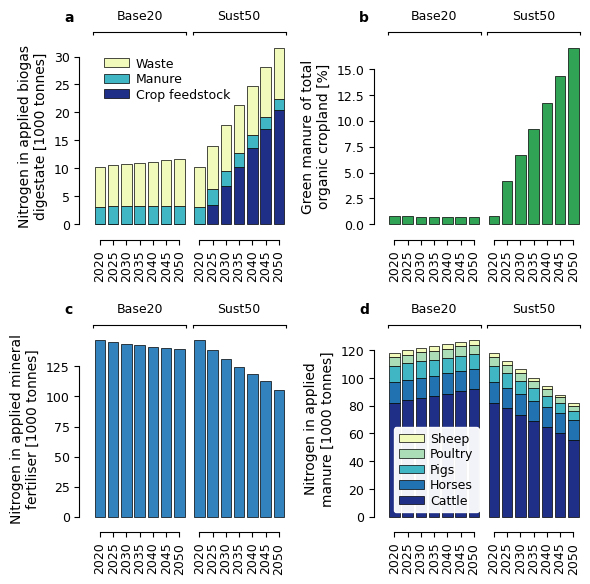

In [10]:
fig, axs = plt.subplots(2,2, figsize=(6,6))

from matplotlib.colors import ListedColormap

plot_data = (
    session.get_attr('w','organic_fertiliser_N','feedstock_type')
    .rename(columns = lambda x: 'Waste' if 'waste' in x else x.capitalize())
    .T.groupby('feedstock_type').sum().T
)/1_000_000

# fig, ax = plt.subplots(figsize=(2.5,2.5))
ax=axs[0,0]
cm.plot.bar(
    plot_data,
    ax=ax,
    group_levels='scn',
    ylabel='Nitrogen in applied biogas\ndigestate [1000 tonnes]',
    **bar_style
)
legend = ax.legend(
    loc='upper left', bbox_to_anchor=(0, 1),
    ncol=1,
    fontsize=9, handletextpad=0.5, labelspacing=0.2,
    frameon=False,
    reverse=True
)
# plt.show()

plot_data = session.get_attr('c','area',{'prod_system':None,'crop':['land_use',None]}).loc[:,('organic','cropland')].apply(lambda x: x/x.sum()*100, axis=1).loc[:,'Green manure']

colors = ['#31a354']
cust_cmap = ListedColormap(name='X', colors=colors)

# fig, ax = plt.subplots(figsize=(2.5,2.5))
ax=axs[0,1]
cm.plot.bar(
    plot_data,
    ax=ax,
    group_levels='scn',
    ylabel='Green manure of total\norganic cropland [%]',
    **{k:v for k,v in bar_style.items() if k != 'cmap'},
    cmap=cust_cmap
)
# plt.show()

display(plot_data)

plot_data = (
    session.get_attr('c','fertiliser.mineral_N','none')
)/1_000_000

colors = ['#3182bd']
cust_cmap = ListedColormap(name='X', colors=colors)

# fig, ax = plt.subplots(figsize=(2.5,2.5))
ax=axs[1,0]
cm.plot.bar(
    plot_data,
    ax=ax,
    group_levels='scn',
    ylabel='Nitrogen in applied mineral\nfertiliser [1000 tonnes]',
    **{k:v for k,v in bar_style.items() if k != 'cmap'},
    cmap=cust_cmap
)
ax.legend().set_visible(False)
# plt.show()
display(plot_data)

plot_data = (
    session.get_attr('c','fertiliser.manure_N','species')
    .rename(columns = lambda x: x.capitalize())
)/1_000_000

# fig, ax = plt.subplots(figsize=(2.5,2.5))
ax=axs[1,1]
cm.plot.bar(
    plot_data,
    ax=ax,
    group_levels='scn',
    ylabel='Nitrogen in applied\nmanure [1000 tonnes]',
    **bar_style
)
# ax.legend(loc='lower left', bbox_to_anchor=(0, 0), ncol=1, fontsize=9, frameon=True, reverse=True)
legend = ax.legend(
    loc='lower left', bbox_to_anchor=(0, 0),
    ncol=1,
    fontsize=9, handletextpad=0.5, labelspacing=0.2,
    frameon=True,
    reverse=True
)
legend.get_frame().set_edgecolor('white')
# legend.get_frame().set_facecolor('white')
legend.get_frame().set_alpha(0.95)
# plt.show()

# Annotate
for i, ax in enumerate(axs.flat):
    ax.text(-0.15, 1.2, chr(97 + i), transform=ax.transAxes, 
            fontsize=10, fontweight='bold', va='top', ha='left')

plt.tight_layout()
plt.show()

In [11]:
session.get_attr('c','fertiliser.mineral_N','prod_system').add(
    session.get_attr('c','fertiliser.manure_N','prod_system')+session.get_attr('c','fertiliser.organic_N','prod_system'),
    fill_value=0
)/1_000_000

prod_system  conventional    organic
scn    year                         
Base20 2020    251.424463  23.882421
       2025    251.757435  24.252312
       2030    251.839778  24.583898
       2035    251.715734  24.866008
       2040    251.845286  25.173081
       2045    252.120768  25.491488
       2050    252.126296  25.756699
Sust50 2020    251.424463  23.882421
       2025    229.079222  35.895119
       2030    208.560611  46.650188
       2035    189.756818  56.169091
       2040    172.846541  64.513117
       2045    157.506162  71.537583
       2050    144.033081  74.561936

Base20, 2020
------------


,Manure (conv.),Manure (org.),Mineral fertiliser,Other organic fertiliser,total
prod_system,,,,,
Conventional\ncropland,40.525223,0.695030,72.282976,4.416144,117.919373
Organic\ncropland,18.324979,41.060204,NaN,4.061014,63.446197


,Manure (conv.),Manure (org.),Mineral fertiliser,Other organic fertiliser
prod_system,,,,
Conventional\ncropland,33.786053,0.579450,60.26263,3.681758
Organic\ncropland,28.734491,64.384469,NaN,6.367875


Sust50, 2050
------------


,Manure (conv.),Manure (org.),Mineral fertiliser,Other organic fertiliser,total
prod_system,,,,,
Conventional\ncropland,26.328877,0.205837,88.147856,0.000000,114.68257
Organic\ncropland,7.943228,24.161860,NaN,26.002592,58.10768


,Manure (conv.),Manure (org.),Mineral fertiliser,Other organic fertiliser
prod_system,,,,
Conventional\ncropland,22.722154,0.177640,76.072713,0.000000
Organic\ncropland,13.390445,40.731303,NaN,43.834351


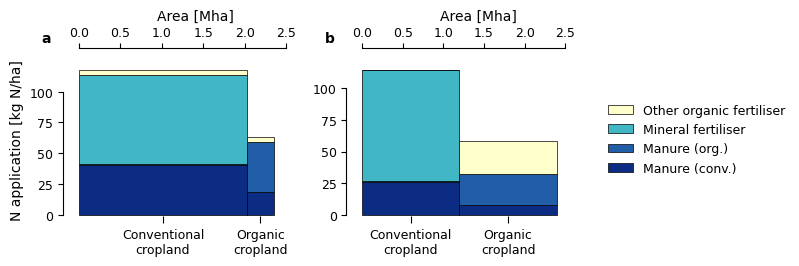

In [12]:
from matplotlib.colors import ListedColormap
colors = ['#0c2c84', '#225ea8', '#41b6c4', '#ffffcc']
cust_cmap = ListedColormap(name='X', colors=colors)

fig, axs = plt.subplots(1,2, figsize=(6.7,2), gridspec_kw={'wspace' : 0.2})

i=0
for scn, year in [('Base20','2020'),('Sust50','2050')]:

    ax = axs[i]
    
    mi = (
        session.get_attr('c','fertiliser.mineral_N',{'crop':'land_use','prod_system':None}).loc[(scn,year),'cropland']
    )
    ma = (
        session.get_attr('c','fertiliser.manure_N',{'crop':'land_use','prod_system':None, 'animal_prod_system':None}).loc[(scn,year),'cropland']
        .unstack()
        .rename(columns={'conventional':'Manure (conv.)', 'organic':'Manure (org.)'})
    )
    
    oo = (
        session.get_attr('c','fertiliser.organic_N',{'crop':'land_use','prod_system':None}).loc[(scn,year),'cropland']
    )
    
    ar = (
        session.get_attr('c','area',{'crop':'land_use', 'prod_system':None}).loc[(scn,year),'cropland']
    )
    
    plot_data = pd.concat([
        ma.div(ar, axis=0),
        mi.div(ar, axis=0).rename('Mineral fertiliser'),
        oo.div(ar, axis=0).rename('Other organic fertiliser'),
        ar.rename('area')/1_000_000
    ], axis=1).rename(index={'conventional':'Conventional\ncropland','organic':'Organic\ncropland'})
    
    cm.plot.marimekko(
        plot_data.fillna(0),
        ax=ax,
        x_column='area',
        cmap=cust_cmap,
        sort_categories=False,
        xlim_pad = 0.2,
        ylim_pad = 0.05,
        xcategorylabels_rotation=0,
        xcategorylabels_halign='center',
        ylabel='N application [kg N/ha]' if i==0 else '',
        xlabel='Area [Mha]',
        ylabel_fontsize=10,
        xlabel_fontsize=10,
        ticklabels_fontsize=9,
        xcategorylabels_fontsize=9
    )

    if i == 1:
        ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=9, frameon=False, reverse=True)
    else:
        ax.legend().set_visible(False)

    table_data = plot_data.drop('area', axis=1)
    table_data['total'] = table_data.sum(axis=1)
    pstr = ', '.join((scn,year))
    print(pstr)
    print('-'*len(pstr))
    display(table_data)
    display(plot_data.div(plot_data.sum(axis=1), axis=0).drop('area', axis=1)*100)
    i += 1

# Annotate
for i, ax in enumerate(axs.flat):
    ax.text(-0.15, 1.2, chr(97 + i), transform=ax.transAxes, 
        fontsize=10, fontweight='bold', va='top', ha='left')

# plt.tight_layout()
plt.show()

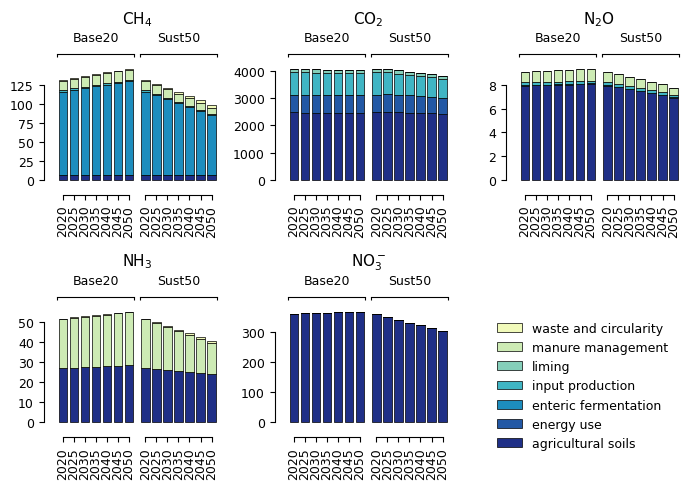

In [13]:
to_comp = {
    'CO2' : 1,
    'CH4bio' : 1,
    'CH4fos' : 1,
    'N2O' : 1,
    'N2O-N' : (44/28),
    'NH3' : 1,
    'NH3-N' : (17/14),
    'NO3-N' : (62/14),
    'NOx' : 1
}

to_comp_names = {
    'N2O' : 'N$_2$O',
    'CO2' : 'CO$_2$',
    'CH4bio' : 'CH$_4$',
    'CH4fos' : 'CH$_4$',
    'N2O-N' : 'N$_2$O',
    'NH3' : 'NH$_3$',
    'NH3-N' : 'NH$_3$',
    'NO3-N' : 'NO$_3^-$',
    'NOx' : 'NO$_X$'
}

ems = (
    cm.impact.get_emissions(session)
    .drop(['NOx-N','CO2bio','N2','NOx'], level='compound', axis=1)
)

plot_data = (
    ems
    .mul([to_comp[cp] for cp in ems.columns.get_level_values('compound')], axis=1)
    .rename(to_comp_names, axis=1)
    .T.groupby(['compound','process']).sum().T
    .stack().unstack().fillna(0)
)/1_000_000

fig, axs = plt.subplots(2,3, figsize=(7,5))
for i, cmp in enumerate(plot_data.columns.unique('compound')):
    ax = axs.flatten()[i]
    cm.plot.bar(
        plot_data.loc[:,cmp],
        group_levels='scn',
        ax=ax,
        **bar_style
    )
    ax.set_title(cmp, fontsize=11)

handles, labels = ax.get_legend_handles_labels()
ax = axs.flatten()[-1]
ax.legend(handles, labels, fontsize=9, frameon=False, reverse=True)
ax.axis('off')

for ax in axs.flatten()[:-1]:
    ax.legend().set_visible(False)

plt.tight_layout()
plt.show()

tab_data = plot_data.T.groupby('compound').sum().T
# tab_data['CO$_2$eq'] = tab_data.mul(pd.Series({'CO$_2$':1, 'CH$_4$':25, 'N$_2$O':298}), axis=1).sum(axis=1)
display((tab_data.div(tab_data.loc[('Base20','2020')], axis=1)*100-100).style.format(precision=0))

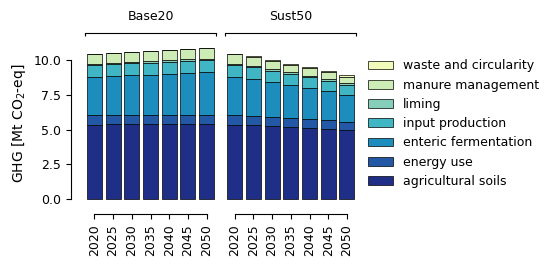

In [14]:
ghg = (
    cm.impact.get_GHG(session)
    .T.groupby('process').sum().T
) / 1_000_000_000 # [Mt]
fig, ax = plt.subplots(1,1, figsize=(3.5,2))
cm.plot.bar(
    ghg,
    group_levels='scn',
    ax=ax,
    ylabel='GHG [Mt CO$_2$-eq]',
    **bar_style
)
ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=9, frameon=False, reverse=True)
plt.show()

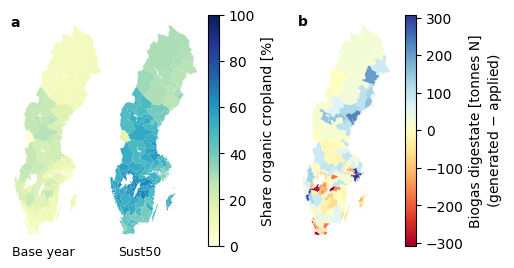

Share organic per region: 16-67%


In [15]:
plot_data1 = (
    session.get_attr('c','area',{'crop':'land_use','region':None,'prod_system':None})
    .loc[:,'cropland']
    .T.groupby('region')
    .apply(lambda x: x/x.sum()*100).xs('organic', level='prod_system')
    .droplevel(0).T
)

fig, axs = plt.subplots(1,3, figsize=(5.5,3), gridspec_kw={'width_ratios' : [1,1.25, 2.2], 'wspace' : 0})

ax=axs[0]
cm.plot.map_from_series(
    plot_data1.loc[('Sust50','2020')],
    vmin=0,
    vmax=100,
    cmap='YlGnBu',
    ax=ax,
    legend=False
)
ax.axis('off')

ax.text(0.35, 0, 'Base year', transform=ax.transAxes, 
        fontsize=9, fontweight='normal', va='top', ha='center')

ax.text(0, 1, 'a', transform=ax.transAxes, 
        fontsize=10, fontweight='bold', va='top', ha='left')

ax=axs[1]
cm.plot.map_from_series(
    plot_data1.loc[('Sust50','2050')],
    vmin=0,
    vmax=100,
    cmap='YlGnBu',
    ax=ax,
    legend=False
)
ax.axis('off')

ax.text(0.35, 0, 'Sust50', transform=ax.transAxes, 
        fontsize=9, fontweight='normal', va='top', ha='center')

cbar = plt.colorbar(ax.collections[0], ax=ax)
cbar.set_label('Share organic cropland [%]', fontsize=10)

plot_data2 = (session.get_attr('w','organic_fertiliser_N','region').loc[('Sust50','2050')] - session.get_attr('c','fertiliser.organic_N','region').loc[('Sust50','2050')]) / 1_000

ax=axs[2]
cm.plot.map_from_series(
    plot_data2,
    ax = ax,
    cmap = 'RdYlBu',
    vmax = plot_data2.abs().quantile(0.95),
    vmin = -plot_data2.abs().quantile(0.95),
    legend = False
)
ax.axis('off')

cbar = plt.colorbar(ax.collections[0], ax=ax)
cbar.set_label('Biogas digestate [tonnes N]\n(generated $\minus$ applied)', fontsize=10)

ax.text(0, 1, 'b', transform=ax.transAxes, 
        fontsize=10, fontweight='bold', va='top', ha='left')

# plt.tight_layout()
plt.show()

print(f"Share organic per region: {plot_data1.loc[('Sust50','2050')].min():.0f}-{plot_data1.loc[('Sust50','2050')].max():.0f}%")

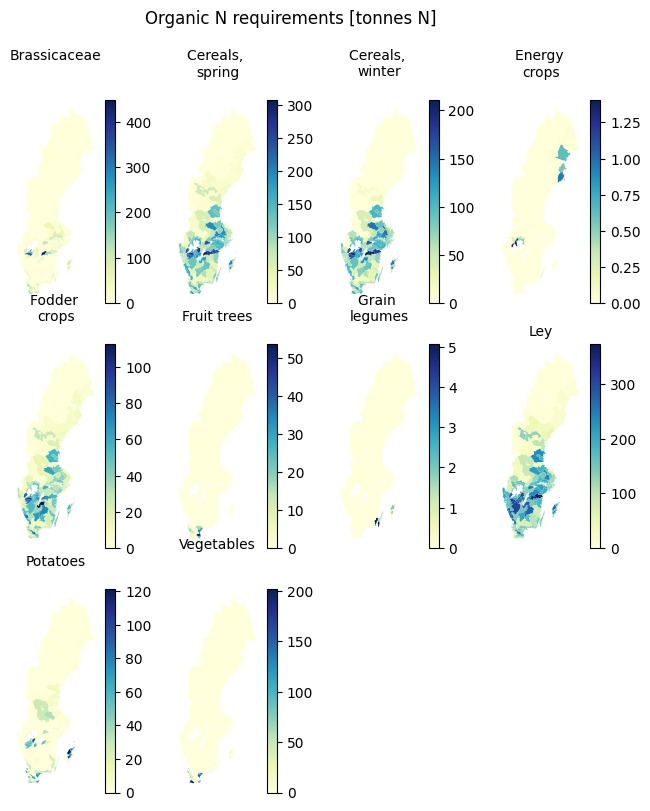

In [17]:
plot_data = (
    session.get_attr('c','fertiliser.TAN_req',{'crop':['land_use','crop_group'],'region':None,'prod_system':None})
    .xs(('cropland','organic'), level=('land_use', 'prod_system'), axis=1)
    # .T.groupby('region')
    # .apply(lambda x: x/x.sum()*100)
    # .droplevel(0).T
)/1000

fig, axs = cm.plot.subplots(
    plot_data.loc[('Sust50','2050')],
    index = 'crop_group',
    plot_fn = cm.plot.map_from_series,
    size=(2, 3),
    title_fontsize=10,
    cmap='YlGnBu'
)
for ax in axs.flatten():
    ax.axis('off')
fig.suptitle('Organic N requirements [tonnes N]')
plt.show()

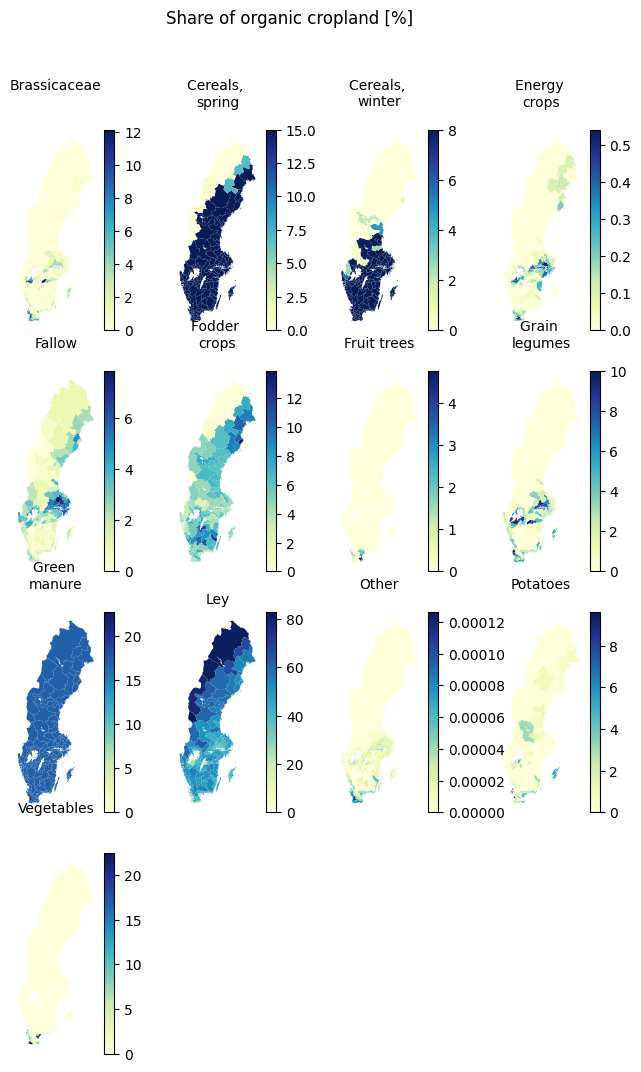

In [18]:
plot_data = (
    session.get_attr('c','area',{'crop':['land_use','crop_group'],'region':None,'prod_system':None})
    .xs(('cropland','organic'), level=('land_use', 'prod_system'), axis=1)
    .T.groupby('region')
    .apply(lambda x: x/x.sum()*100)
    .droplevel(0).T
)

fig, axs = cm.plot.subplots(
    plot_data.loc[('Sust50','2050')],
    index = 'crop_group',
    plot_fn = cm.plot.map_from_series,
    size=(2, 3),
    title_fontsize=10,
    vmin=0,
    cmap='YlGnBu'
)
for ax in axs.flatten():
    ax.axis('off')
fig.suptitle('Share of organic cropland [%]')
plt.show()

In [19]:
session.get_attr('c','fertiliser.crop_residues_N_soil_loss',['crop']).apply(lambda x: x/x.sum()*100, axis=1).loc[:,'Green manure']

scn     year
Base20  2020    0.156441
        2025    0.154413
        2030    0.152603
        2035    0.150972
        2040    0.149262
        2045    0.147551
        2050    0.146080
Sust50  2020    0.156441
        2025    1.212748
        2030    2.504853
        2035    4.017391
        2040    5.722687
        2045    7.638940
        2050    9.629692
Name: Green manure, dtype: float64

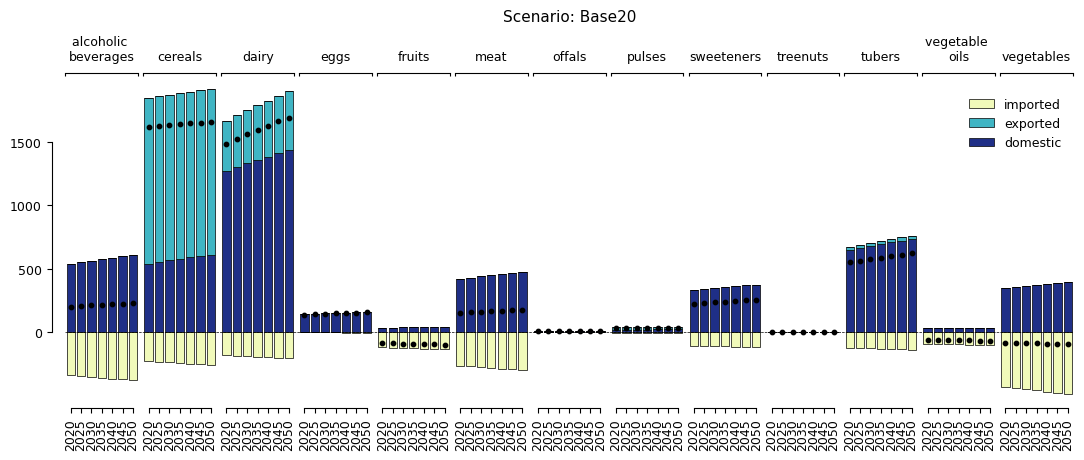

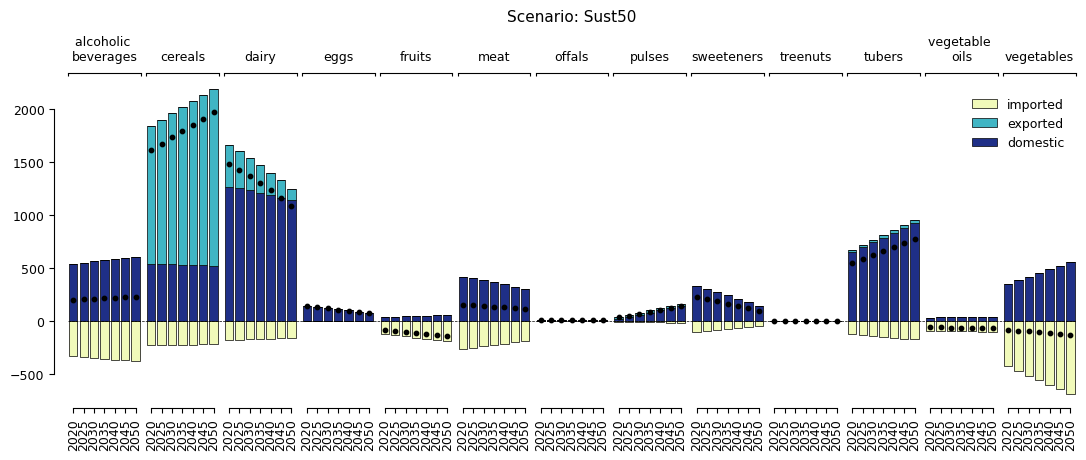

In [20]:
plot_data = (
    session.get_attr(
        module='D',
        attr='food_demand_to_processing',
        groupby=['origin','food_group']
    ).add(
        session.get_attr(
            module='D',
            attr='export_demand',
            groupby=['origin','food_group']
        ).rename(columns={'domestic':'exported'}),
        fill_value = 0
    )
    .stack()
    .fillna(0)
)/1000000
plot_data.loc[:,'imported'] = -plot_data.loc[:,'imported']

for scn in session.scenarios():
    fig, ax = plt.subplots(figsize=(13,4))
    cm.plot.bar(plot_data.loc[scn], group_levels='food_group', grouptitle=f'Scenario: {scn}', ax=ax, **bar_style)
    plt.show()